In [1]:
#Импорт необходимых библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Чтение данных
data = pd.read_excel("/content/Данные_для_курсовои_Классическое_МО.xlsx")

print(data.head())  # вывод первых строк
print(data.describe())  # сводная статистика

   Unnamed: 0    IC50, mM    CC50, mM         SI  MaxAbsEStateIndex  \
0           0    6.239374  175.482382  28.125000           5.094096   
1           1    0.771831    5.402819   7.000000           3.961417   
2           2  223.808778  161.142320   0.720000           2.627117   
3           3    1.705624  107.855654  63.235294           5.097360   
4           4  107.131532  139.270991   1.300000           5.150510   

   MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex       qed        SPS  \
0        5.094096           0.387225        0.387225  0.417362  42.928571   
1        3.961417           0.533868        0.533868  0.462473  45.214286   
2        2.627117           0.543231        0.543231  0.260923  42.187500   
3        5.097360           0.390603        0.390603  0.377846  41.862069   
4        5.150510           0.270476        0.270476  0.429038  36.514286   

   ...  fr_sulfide  fr_sulfonamd  fr_sulfone  fr_term_acetylene  fr_tetrazole  \
0  ...           0           

In [3]:
#Проверяем пропущенные значения
missing_values = data.isnull().sum().sum()
print(f"Общее количество пустых значений: {missing_values}") # выведем кол-во пустых

Общее количество пустых значений: 36


Датасет содержит 1 000 строк, 214 столбцов со значениями типа float64 и int64, 36 значений Nan.
Столбец Unnamed не несет для нас пользы, поэтому будет удален. Замену NaN значений следует проводить осторожно, так как датасет небольшой, есть вероятность изменить качество данных.


In [4]:
#удаляем столбец Unnnamed:0
data = data.drop(['Unnamed: 0'], axis=1)
data.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [5]:
#Стандартизация и удаление лишних данных
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.select_dtypes(include=['float64']))
data_scaled = pd.DataFrame(scaled_data, columns=data.select_dtypes(include=['float64']).columns)

In [6]:
data.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Замена всех NaN на 0.
data = data.fillna(0)

# Проверка корректности преобразования.
NaNs_count = data.isna().sum().sum()
print(f"Общее количество пустых значений: {NaNs_count}")


Общее количество пустых значений: 0


Напишем функцию для визуализации признаков

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def visualize_column(dataset, column_name):
    sns.set(style="whitegrid", font_scale=0.5)
    indices = dataset.index
    step = max(1, len(indices) // 60)

    # Столбчатая диаграмма
    plt.figure(figsize=(10, 4))
    sns.barplot(
        data=dataset,
        x=indices,
        y=column_name,
        palette="viridis",
        alpha=0.8,
        edgecolor='black',
        linewidth=1
    )
    plt.title(f"Столбчатая диаграмма значений {column_name}", pad=20)
    plt.xlabel("Номер наблюдения или категория")
    plt.ylabel(column_name)
    plt.xticks(
        ticks=indices[::step],
        labels=indices[::step],
        rotation=90,
        ha='center',
        fontsize=6,
        fontweight='bold'
    )
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Комплексная визуализация
    sns.set(style="whitegrid")
    plt.figure(figsize=(25, 10))

    # Ящик с усами (boxplot)
    plt.subplot(1, 5, 1)
    sns.boxplot(y=dataset[column_name], color='skyblue')
    plt.title('Boxplot (Ящик с усами)', pad=20)
    plt.ylabel('Значения')

    # Скрипичная диаграмма (violin plot)
    plt.subplot(1, 5, 2)
    sns.violinplot(y=dataset[column_name], color='lightgreen')
    plt.title('Violinplot (Скрипичная диаграмма)', pad=20)
    plt.ylabel('')

    # Точечная диаграмма (swarmplot)
    plt.subplot(1, 5, 3)
    sns.swarmplot(data=dataset, y=column_name, color="blue", size=3)
    plt.title(f"Точечное распределение {column_name}", pad=20)
    plt.ylabel(f"{column_name} (значения)")
    plt.xlabel("Наблюдения")

    # Точечный график с размером точек (scatterplot)
    plt.subplot(1, 5, 4)
    scatter = sns.scatterplot(
        data=dataset,
        x=indices,
        y=column_name,
        hue=column_name,
        palette="viridis",
        size=column_name,
        sizes=(20, 200),
        alpha=0.7,
        edgecolor='black'
    )
    plt.title(f"Точечный график значений {column_name}", pad=20)
    plt.xlabel("Номер наблюдения")
    plt.ylabel(column_name)
    plt.xticks(rotation=45)
    plt.colorbar(scatter.collections[0], label=f'Концентрация {column_name}')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Гистограмма с KDE (kernel density estimation)
    plt.subplot(1, 5, 5)
    sns.histplot(data=dataset, x=dataset[column_name], kde=True, bins=40, color="skyblue")
    plt.title(f"Гистограмма столбца {column_name}", pad=20)
    plt.xlabel(column_name)
    plt.ylabel("Частота")

    plt.tight_layout()
    plt.show()

    # Анализ выбросов
    Qrt1 = dataset[column_name].quantile(0.25)
    Qrt3 = dataset[column_name].quantile(0.75)
    IQR = Qrt3 - Qrt1
    outliers = dataset[(dataset[column_name] < (Qrt1 - 1.5 * IQR)) | (dataset[column_name] > (Qrt3 + 1.5 * IQR))]
    print(f'\nАнализ выбросов:')
    print(f'- Количество выбросов по {column_name}: {outliers.shape[0]}')
    print(f'- Нижняя граница (нижний квантиль минус 1.5*IQR): {Qrt1 - 1.5 * IQR:.3f}')
    print(f'- Верхняя граница (верхний квантиль плюс 1.5*IQR): {Qrt3 + 1.5 * IQR:.3f}\n')

# Посмотрим качество данных по целевой переменной IC50

In [21]:
data_for_IC50 = data.drop(['CC50, mM', 'SI'], axis=1)


/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


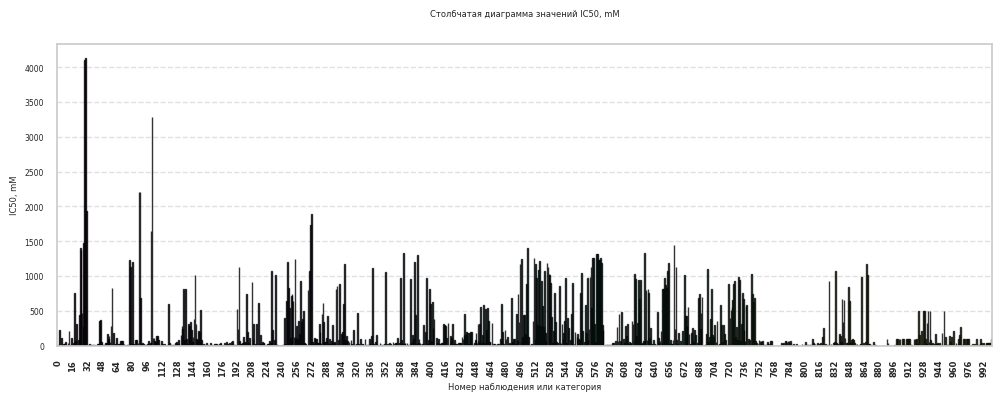

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


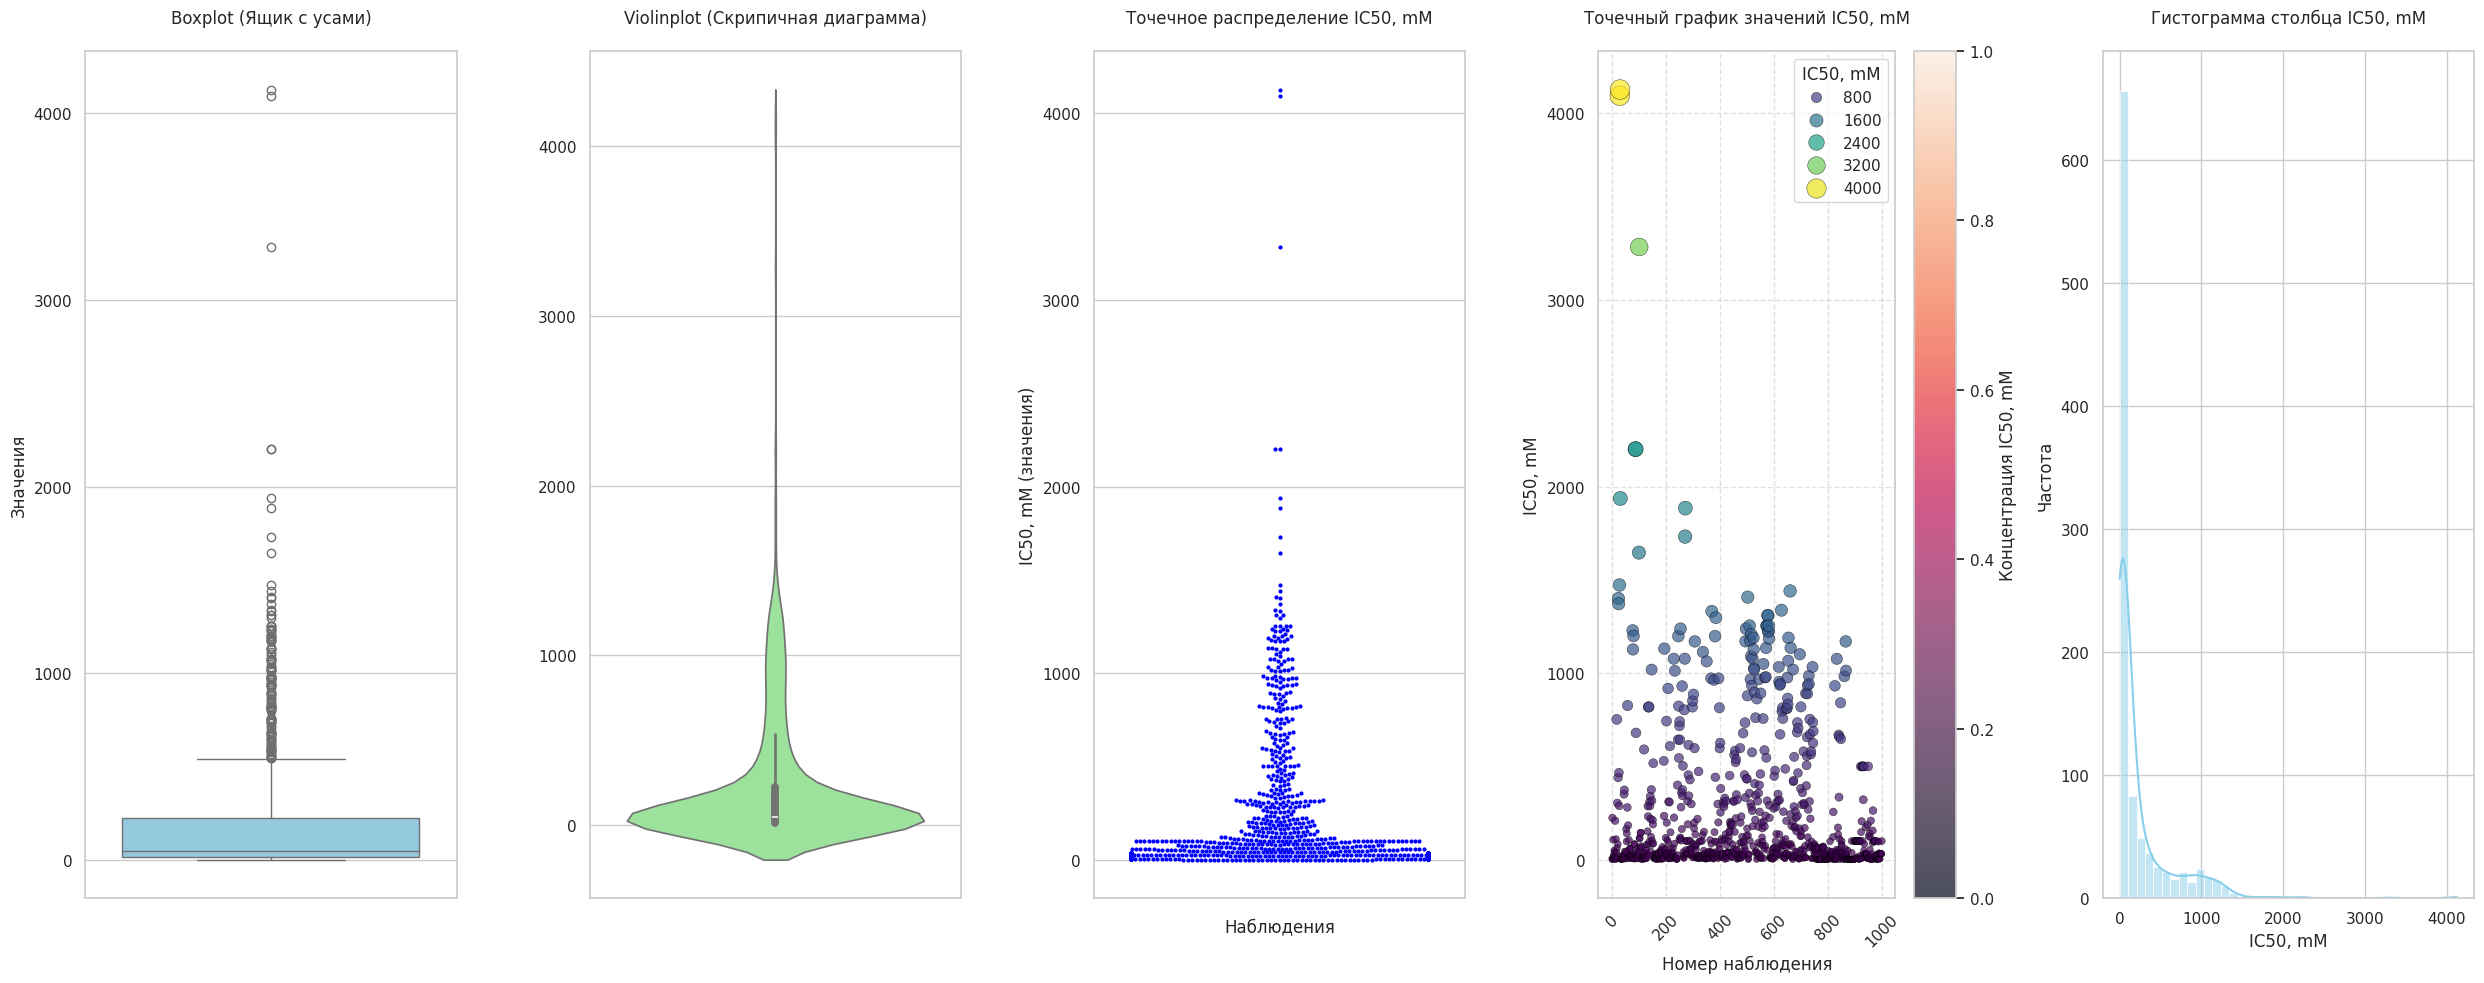


Анализ выбросов:
- Количество выбросов по IC50, mM: 147
- Нижняя граница (нижний квантиль минус 1.5*IQR): -306.175
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 543.667



In [22]:
visualize_column(data_for_IC50, 'IC50, mM')

Распределение значений показателя IC50 не нормальное. Судя по графикам, верхняя граница, за которой начинаются выбросы, равна 543.

In [14]:
## Сформируем новый датасет, в котором будут только те наблюдения, где IC50 меньше 543 мМ.
data_for_IC50[data_for_IC50['IC50, mM'] <= 543].info()

<class 'pandas.core.frame.DataFrame'>
Index: 854 entries, 0 to 1000
Columns: 211 entries, IC50, mM to fr_urea
dtypes: float64(105), int64(106)
memory usage: 1.4 MB


In [15]:
## Сформируем новый датасет, в котором будут только те наблюдения, где IC50 меньше 543 мМ.
## Новый датасет будет содержать в названии 854, что соответствует количеству наблюдений в нем.
data_for_IC50_854 = data_for_IC50[data_for_IC50['IC50, mM'] <= 543]

data_for_IC50_854.info()

<class 'pandas.core.frame.DataFrame'>
Index: 854 entries, 0 to 1000
Columns: 211 entries, IC50, mM to fr_urea
dtypes: float64(105), int64(106)
memory usage: 1.4 MB


/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


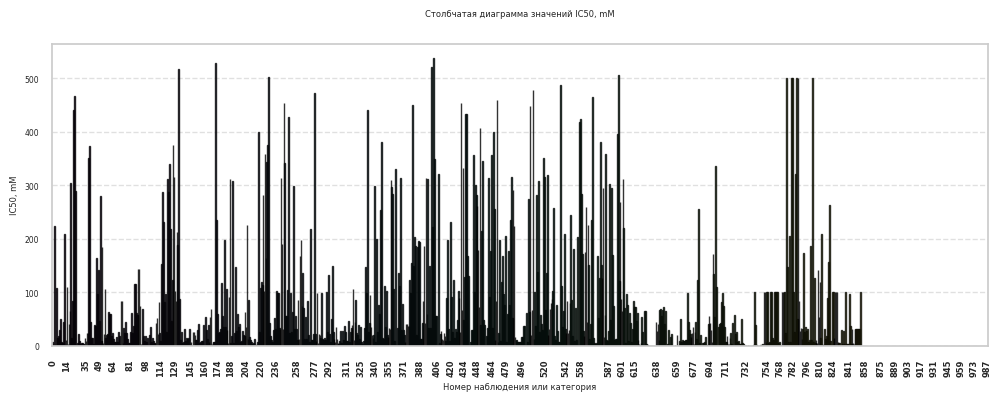

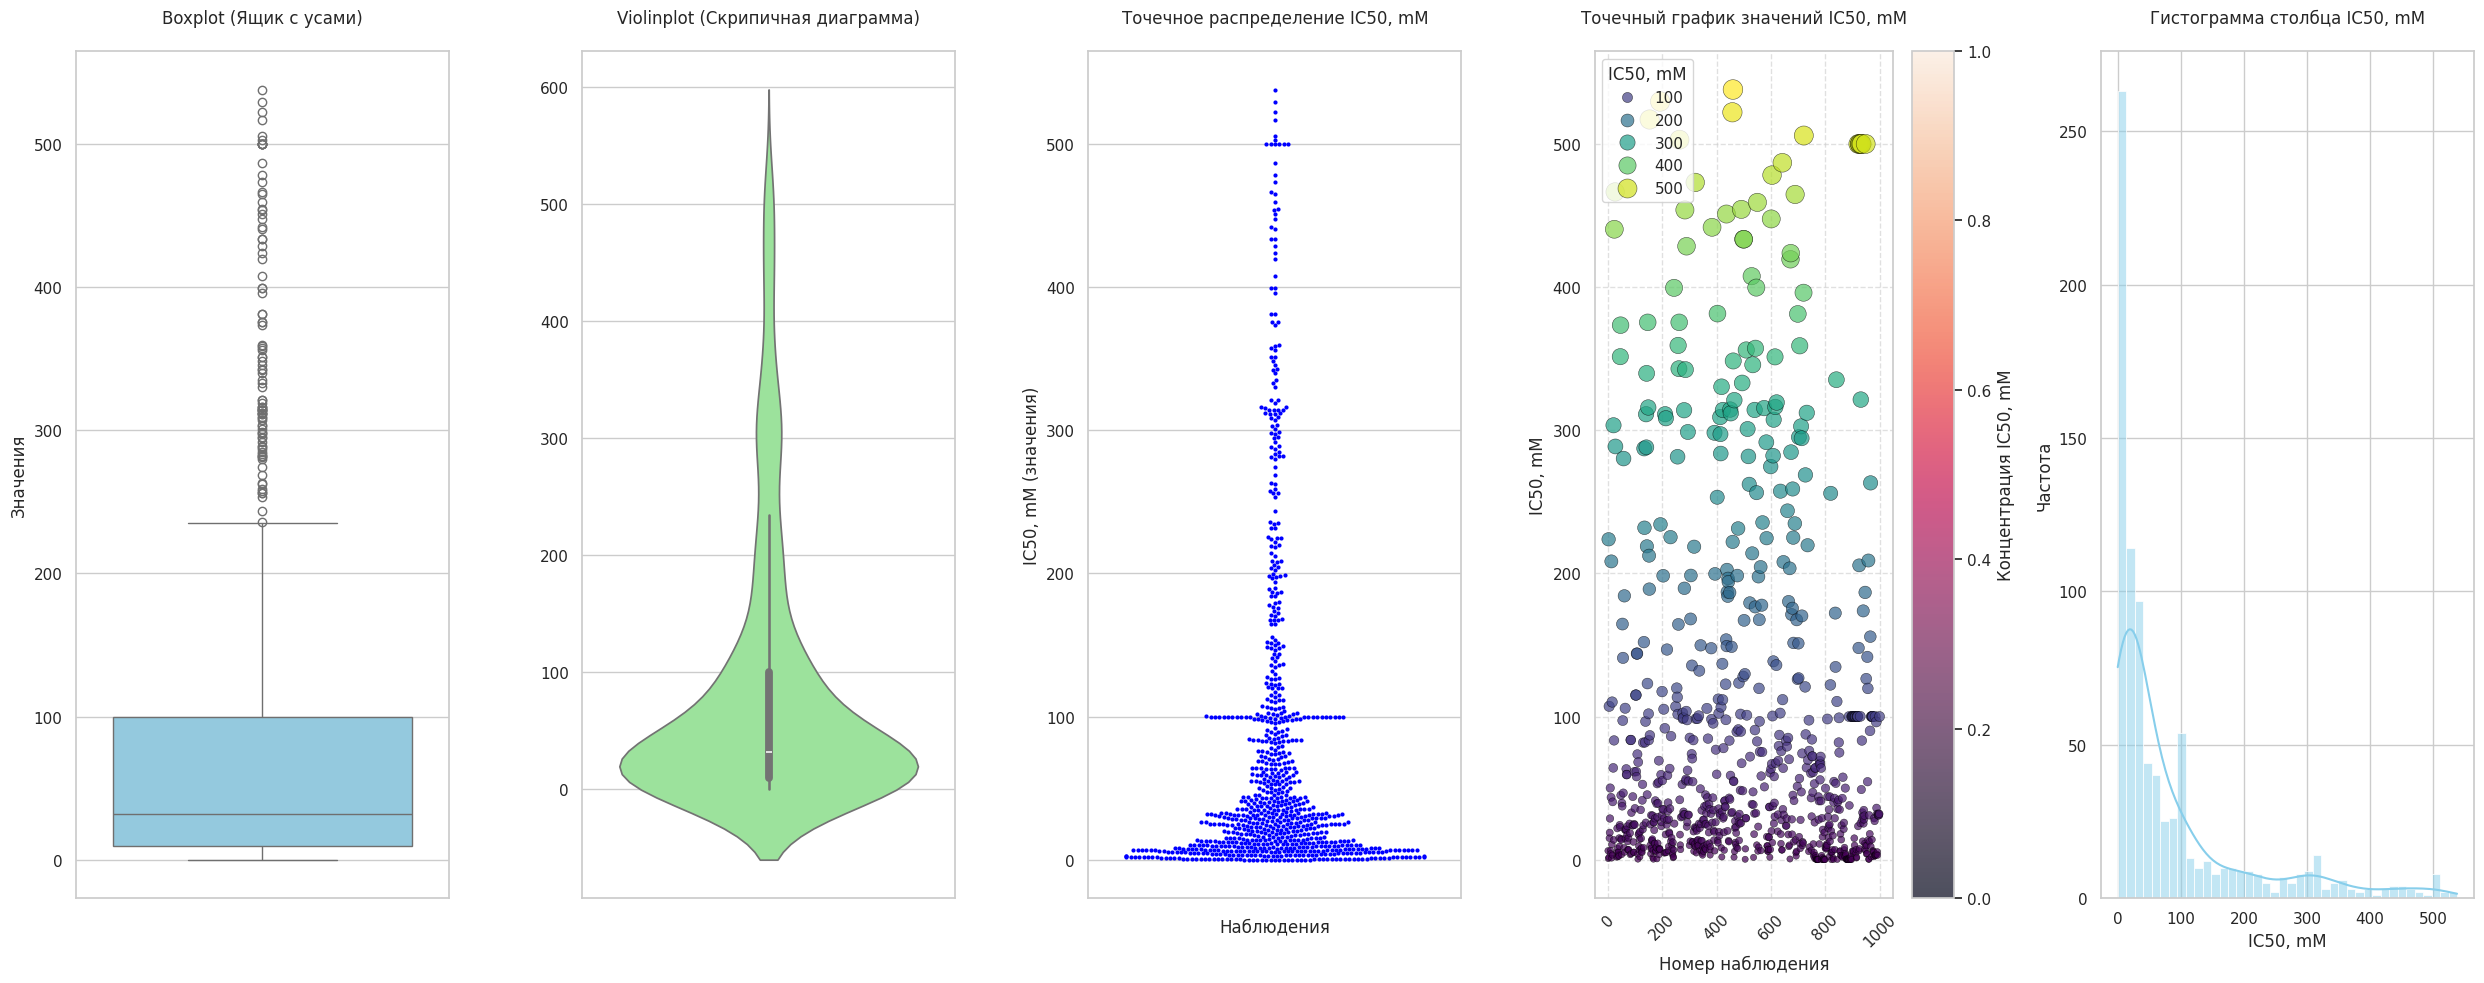


Анализ выбросов:
- Количество выбросов по IC50, mM: 98
- Нижняя граница (нижний квантиль минус 1.5*IQR): -125.490
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 235.294



In [16]:
# Вывод информации о столбцах датасета dataset_for_IC50_854
visualize_column(data_for_IC50_854, 'IC50, mM')

Выбросов значительно меньше

# Посмотрим качество данных по целевой переменной CC50

In [28]:
data_for_CC50 = data.drop(['IC50, mM', 'SI'], axis=1)


/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


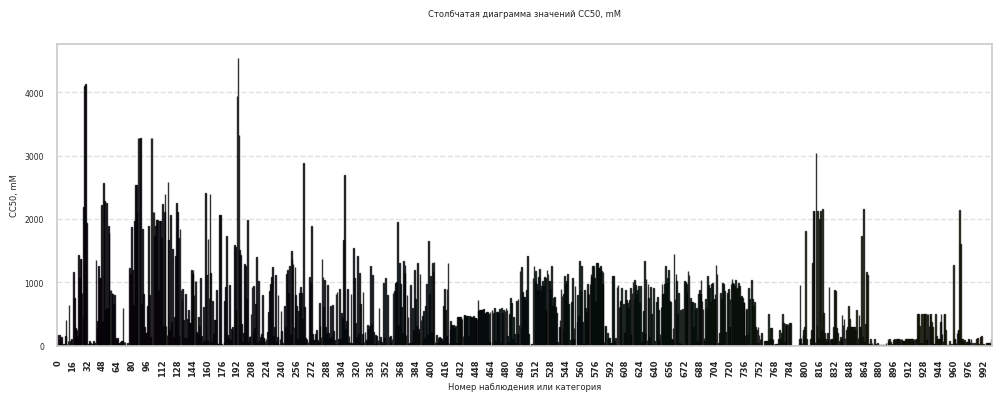

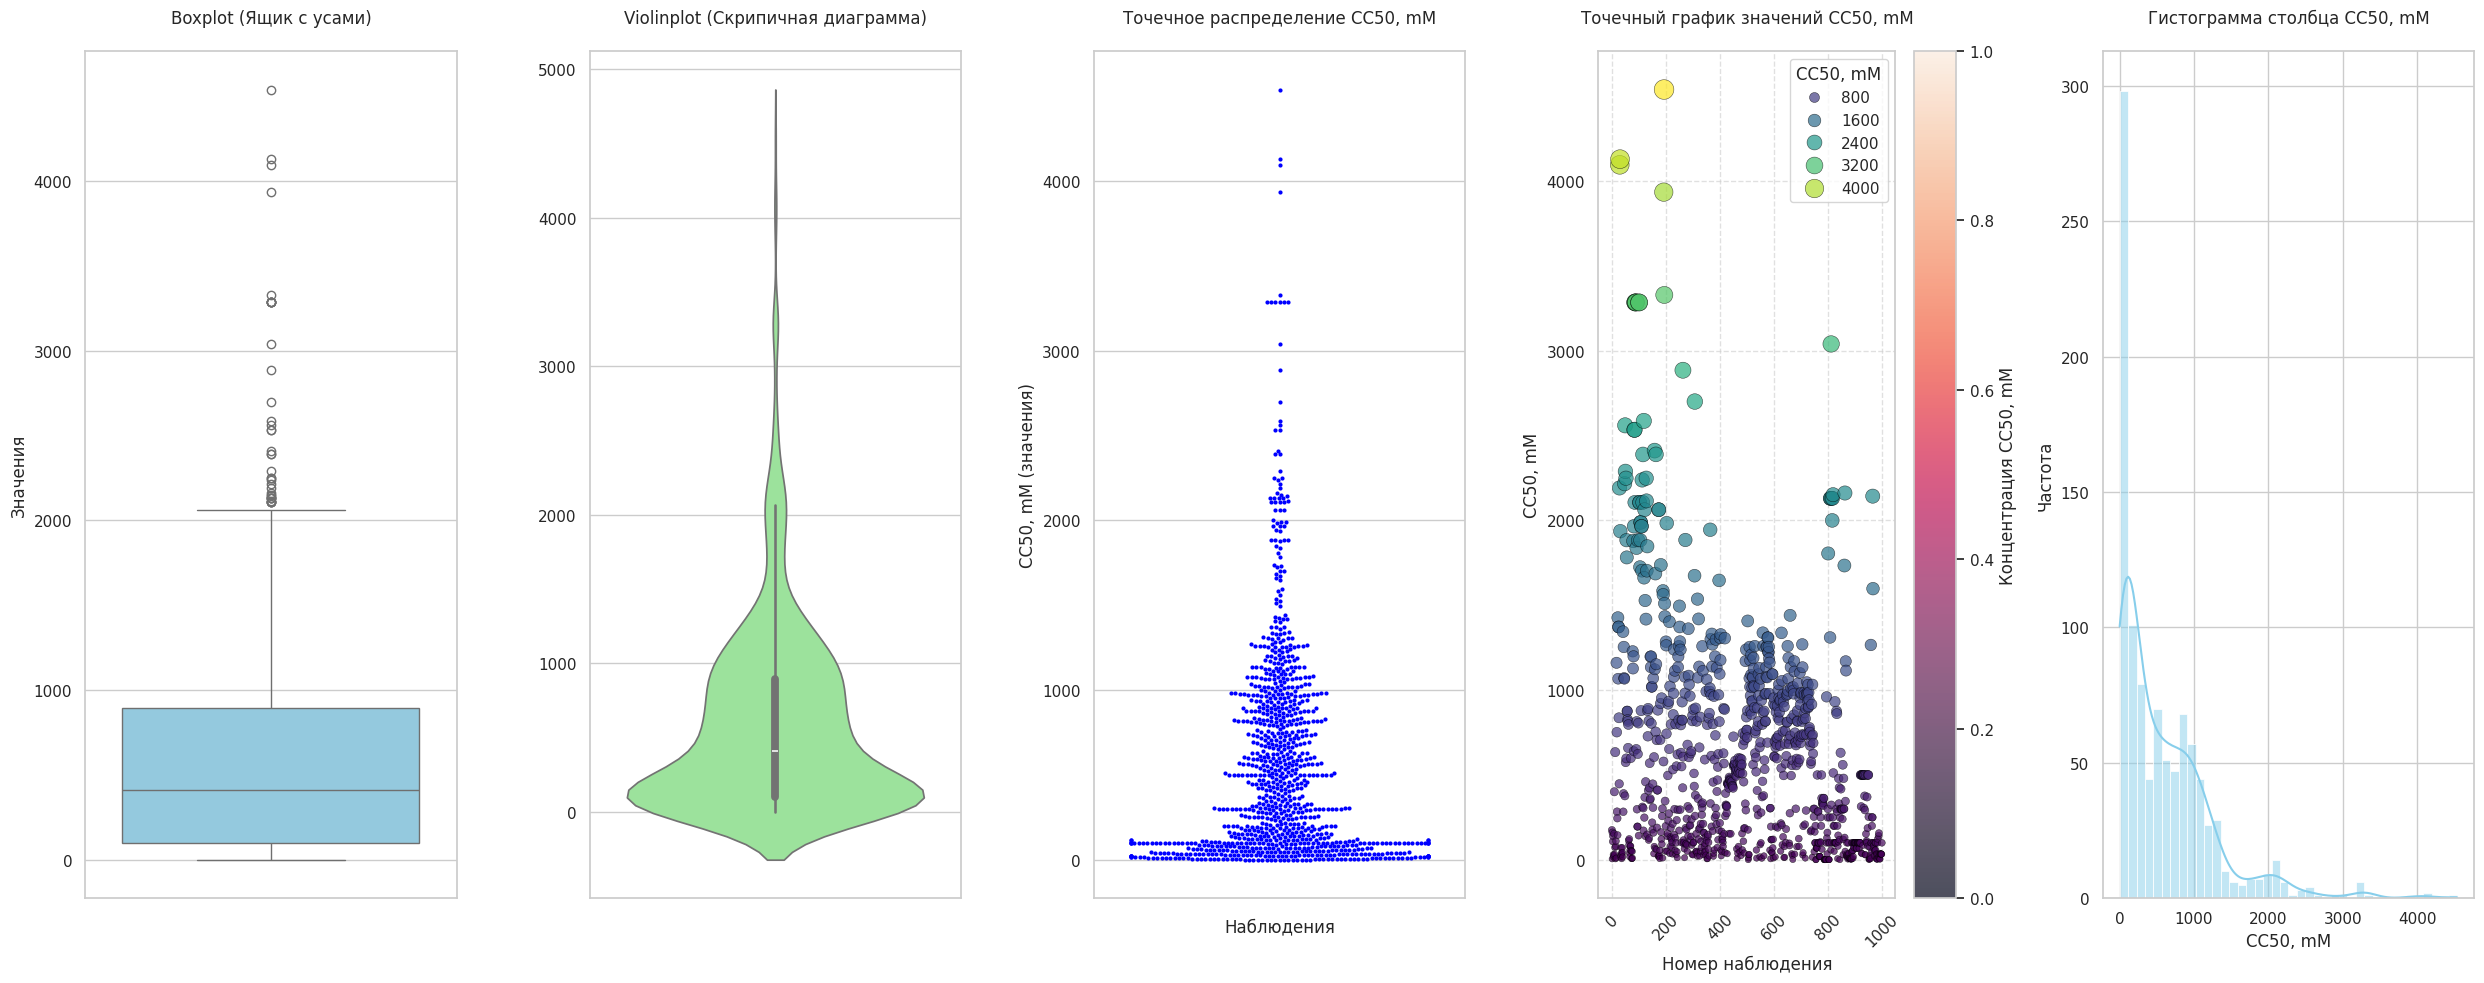


Анализ выбросов:
- Количество выбросов по CC50, mM: 39
- Нижняя граница (нижний квантиль минус 1.5*IQR): -1091.136
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 2085.224



In [24]:
visualize_column(data_for_CC50, 'CC50, mM')

Распределение значений показателя CC50 не нормальное. Судя по графикам, верхняя граница, за которой начинаются выбросы, равна 2085.

In [30]:
## Сформируем новый датасет, в котором будут только те наблюдения, где СС50 меньше 2085 мМ.
data_for_CC50[data_for_CC50['CC50, mM'] <= 2085].info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 0 to 1000
Columns: 211 entries, CC50, mM to fr_urea
dtypes: float64(105), int64(106)
memory usage: 1.6 MB


In [31]:
# Новый датасет будет содержать в названии 962, что соответствует количеству наблюдений в нем.
data_for_CC50_962 = data_for_CC50[data_for_CC50['CC50, mM'] <= 2085]

data_for_CC50_962.info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 0 to 1000
Columns: 211 entries, CC50, mM to fr_urea
dtypes: float64(105), int64(106)
memory usage: 1.6 MB


/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


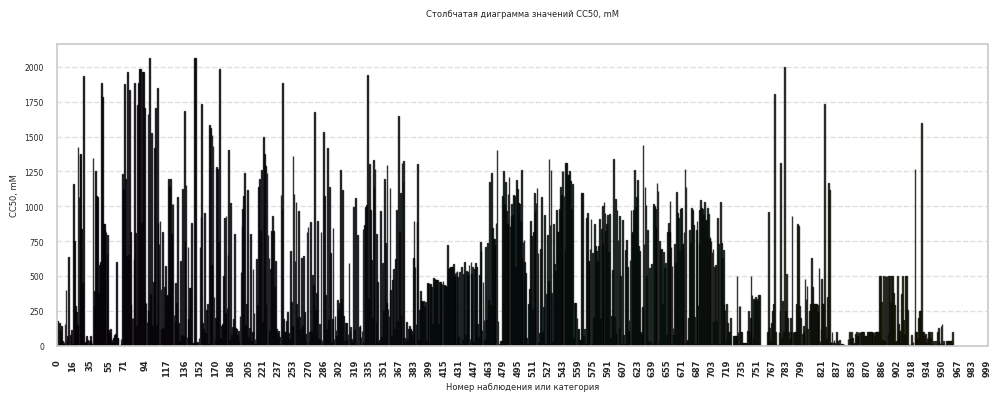

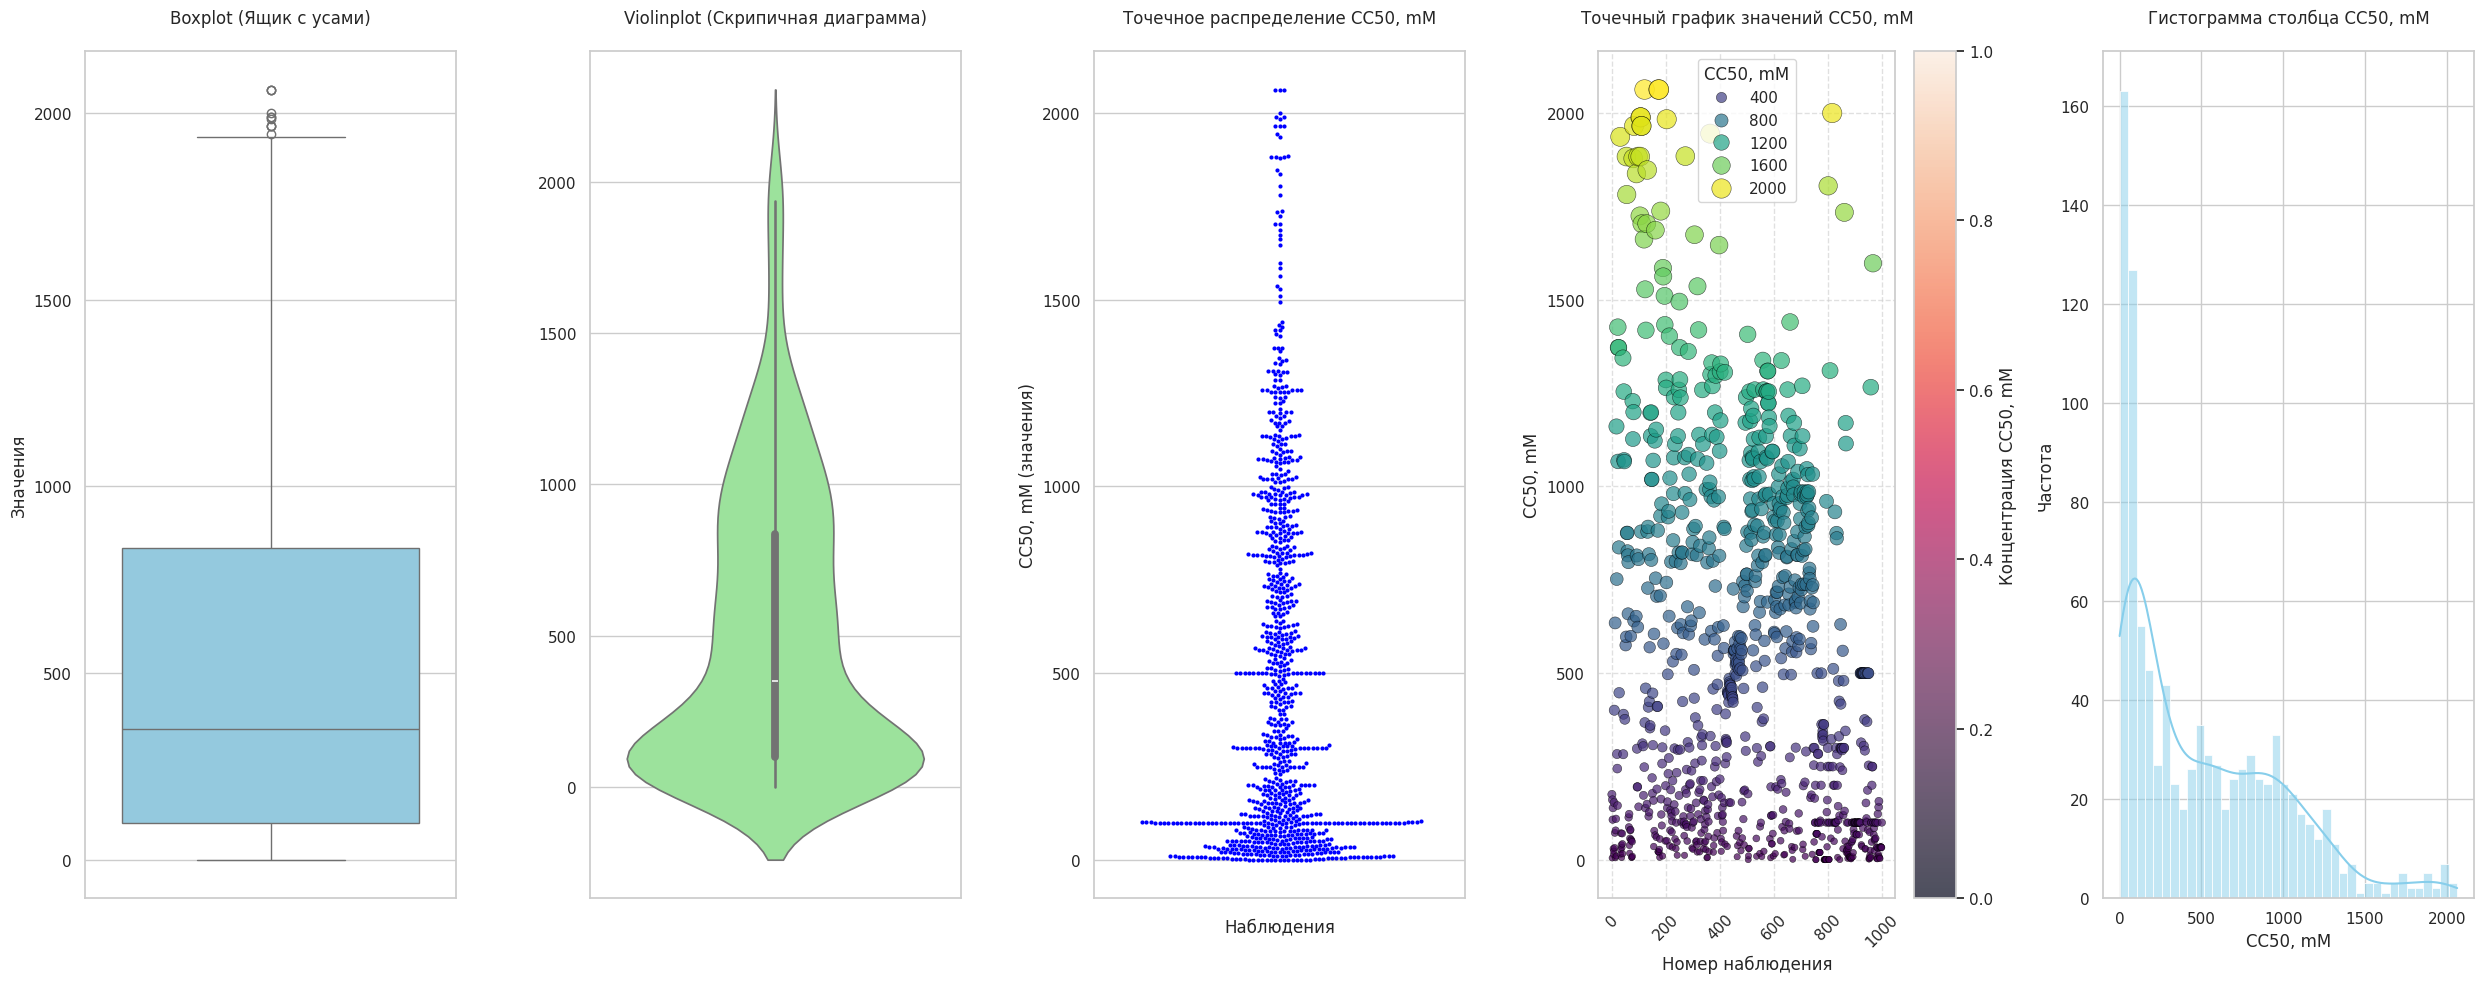


Анализ выбросов:
- Количество выбросов по CC50, mM: 11
- Нижняя граница (нижний квантиль минус 1.5*IQR): -1004.427
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 1940.708



In [32]:
# Вывод информации о столбцах датасета data_for_CC50_962
visualize_column(data_for_CC50_962, 'CC50, mM')

# Посмотрим качество данных по целевой переменной SI

In [34]:
data_for_SI = data.drop(['CC50, mM', 'IC50, mM'], axis=1)


/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


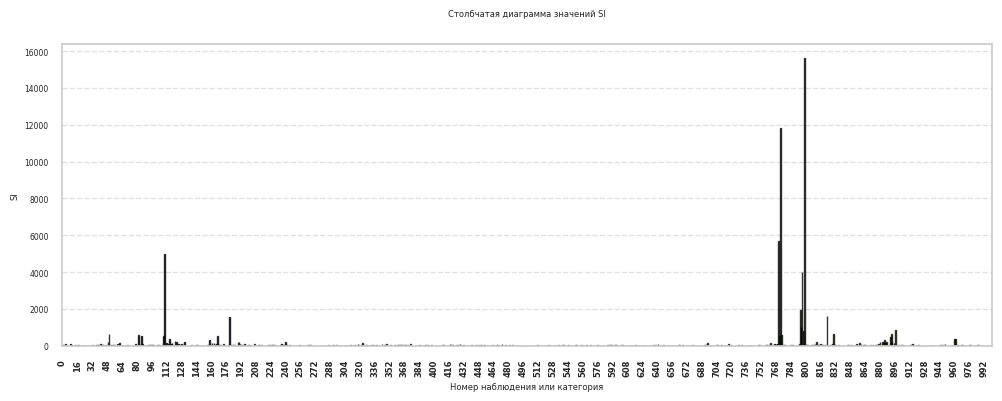

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 37.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 85.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


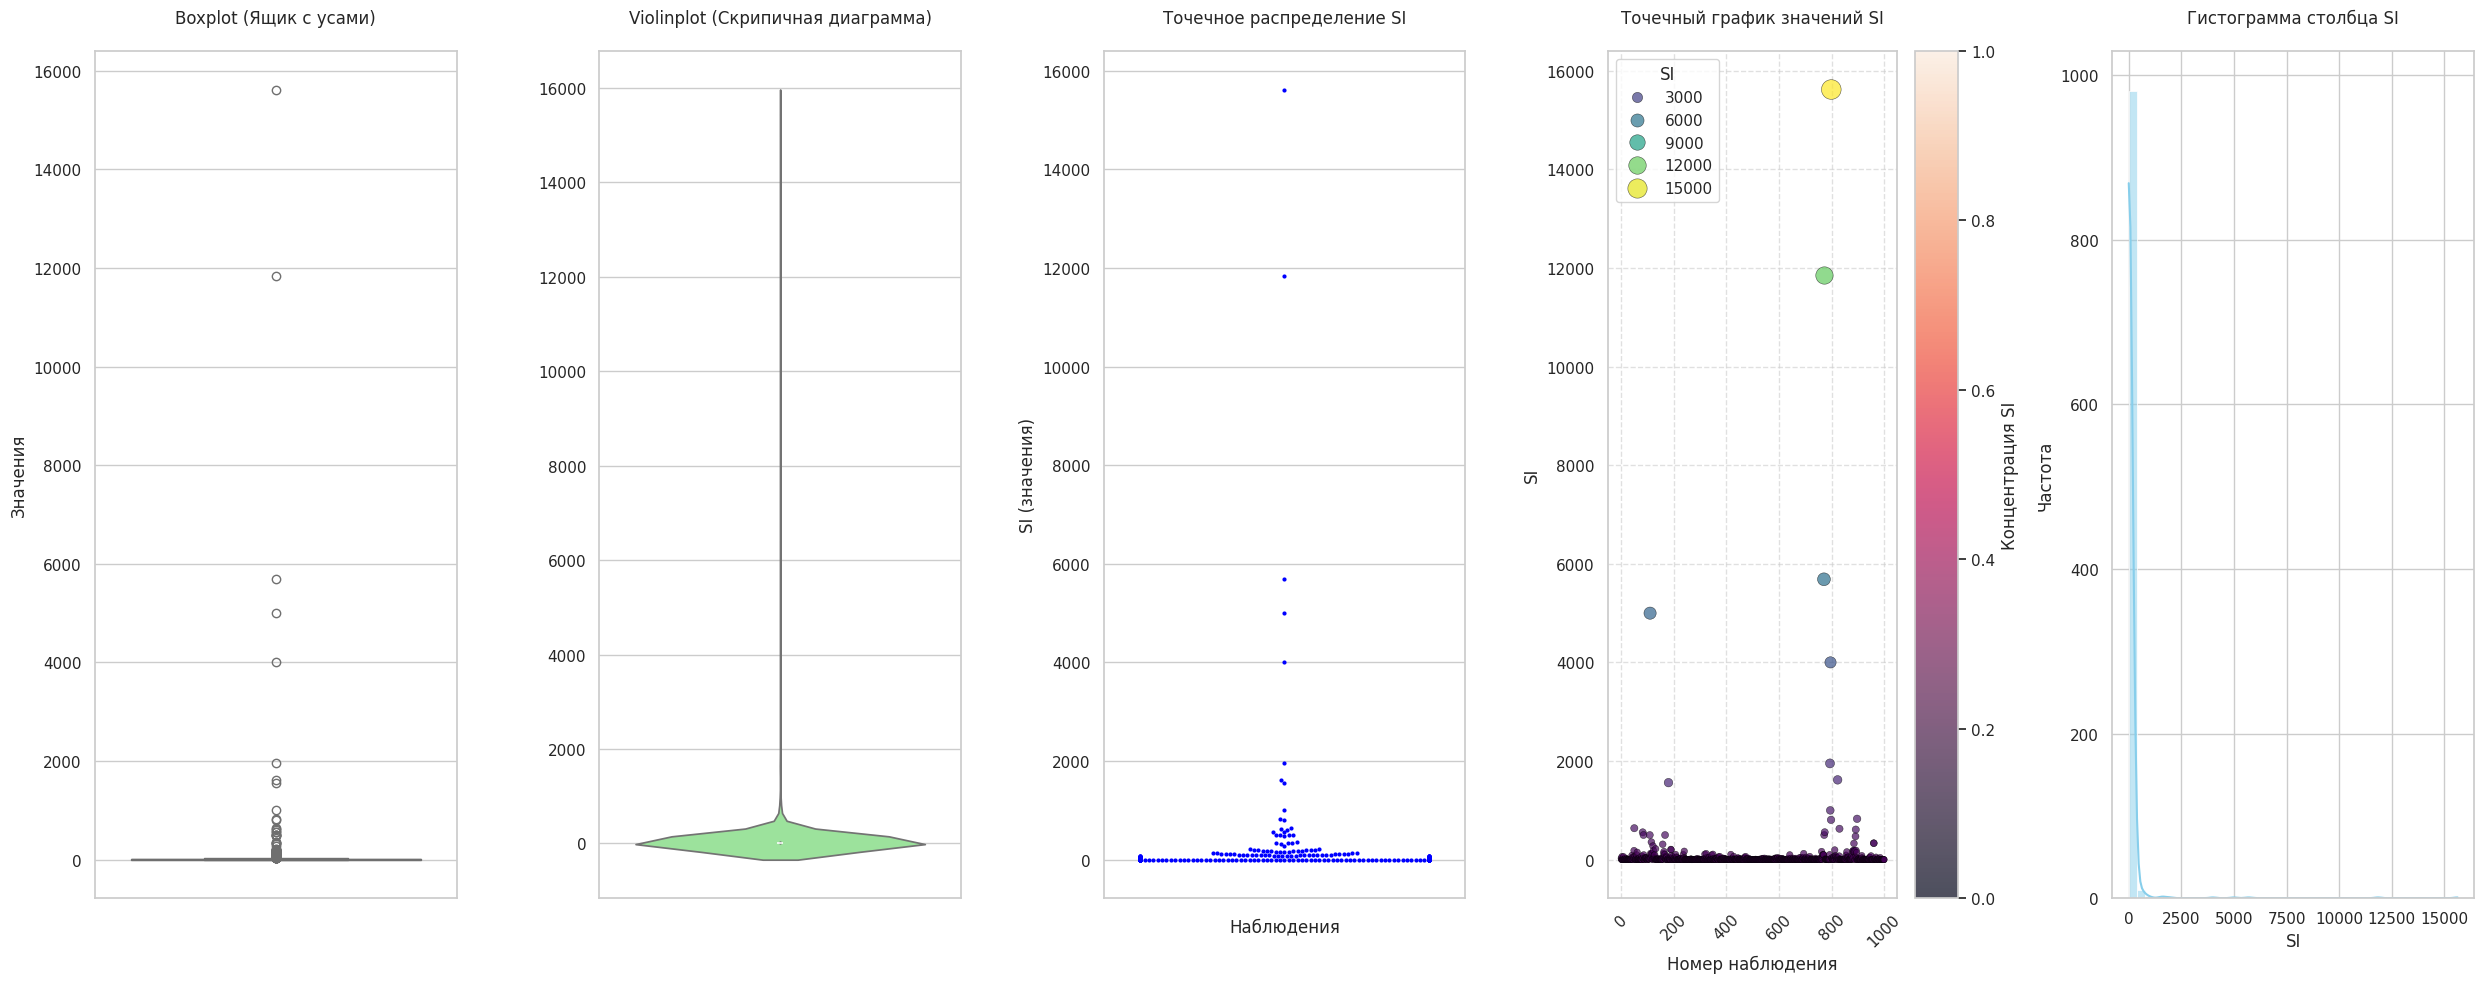


Анализ выбросов:
- Количество выбросов по SI: 125
- Нижняя граница (нижний квантиль минус 1.5*IQR): -21.267
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 39.267



In [35]:
visualize_column(data_for_SI, 'SI')

Распределение значений показателя SI не нормальное. Судя по графикам, верхняя граница, за которой начинаются выбросы, равна 39.

In [36]:
## Сформируем новый датасет, в котором будут только те наблюдения, где SI меньше 39 мМ.
data_for_SI[data_for_SI['SI'] <= 39].info()
data_for_SI = data_for_SI[data_for_SI['SI'] <= 39]

data_for_SI.info()

<class 'pandas.core.frame.DataFrame'>
Index: 876 entries, 0 to 1000
Columns: 211 entries, SI to fr_urea
dtypes: float64(105), int64(106)
memory usage: 1.4 MB
<class 'pandas.core.frame.DataFrame'>
Index: 876 entries, 0 to 1000
Columns: 211 entries, SI to fr_urea
dtypes: float64(105), int64(106)
memory usage: 1.4 MB


/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


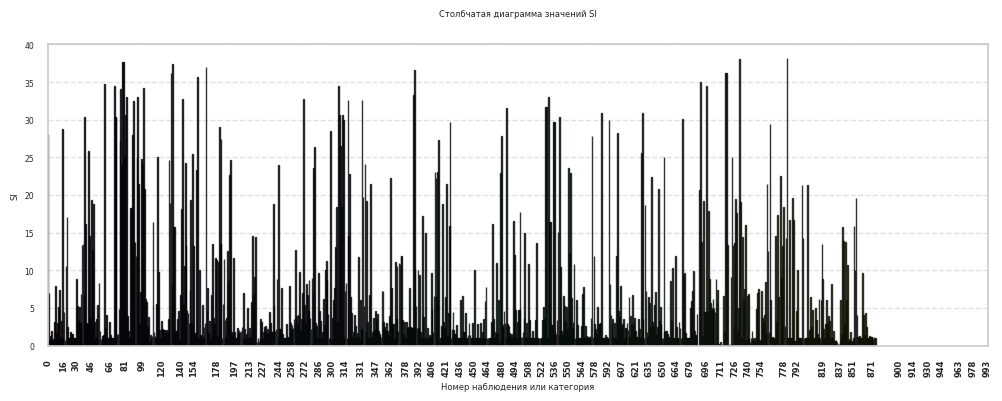

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 11.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


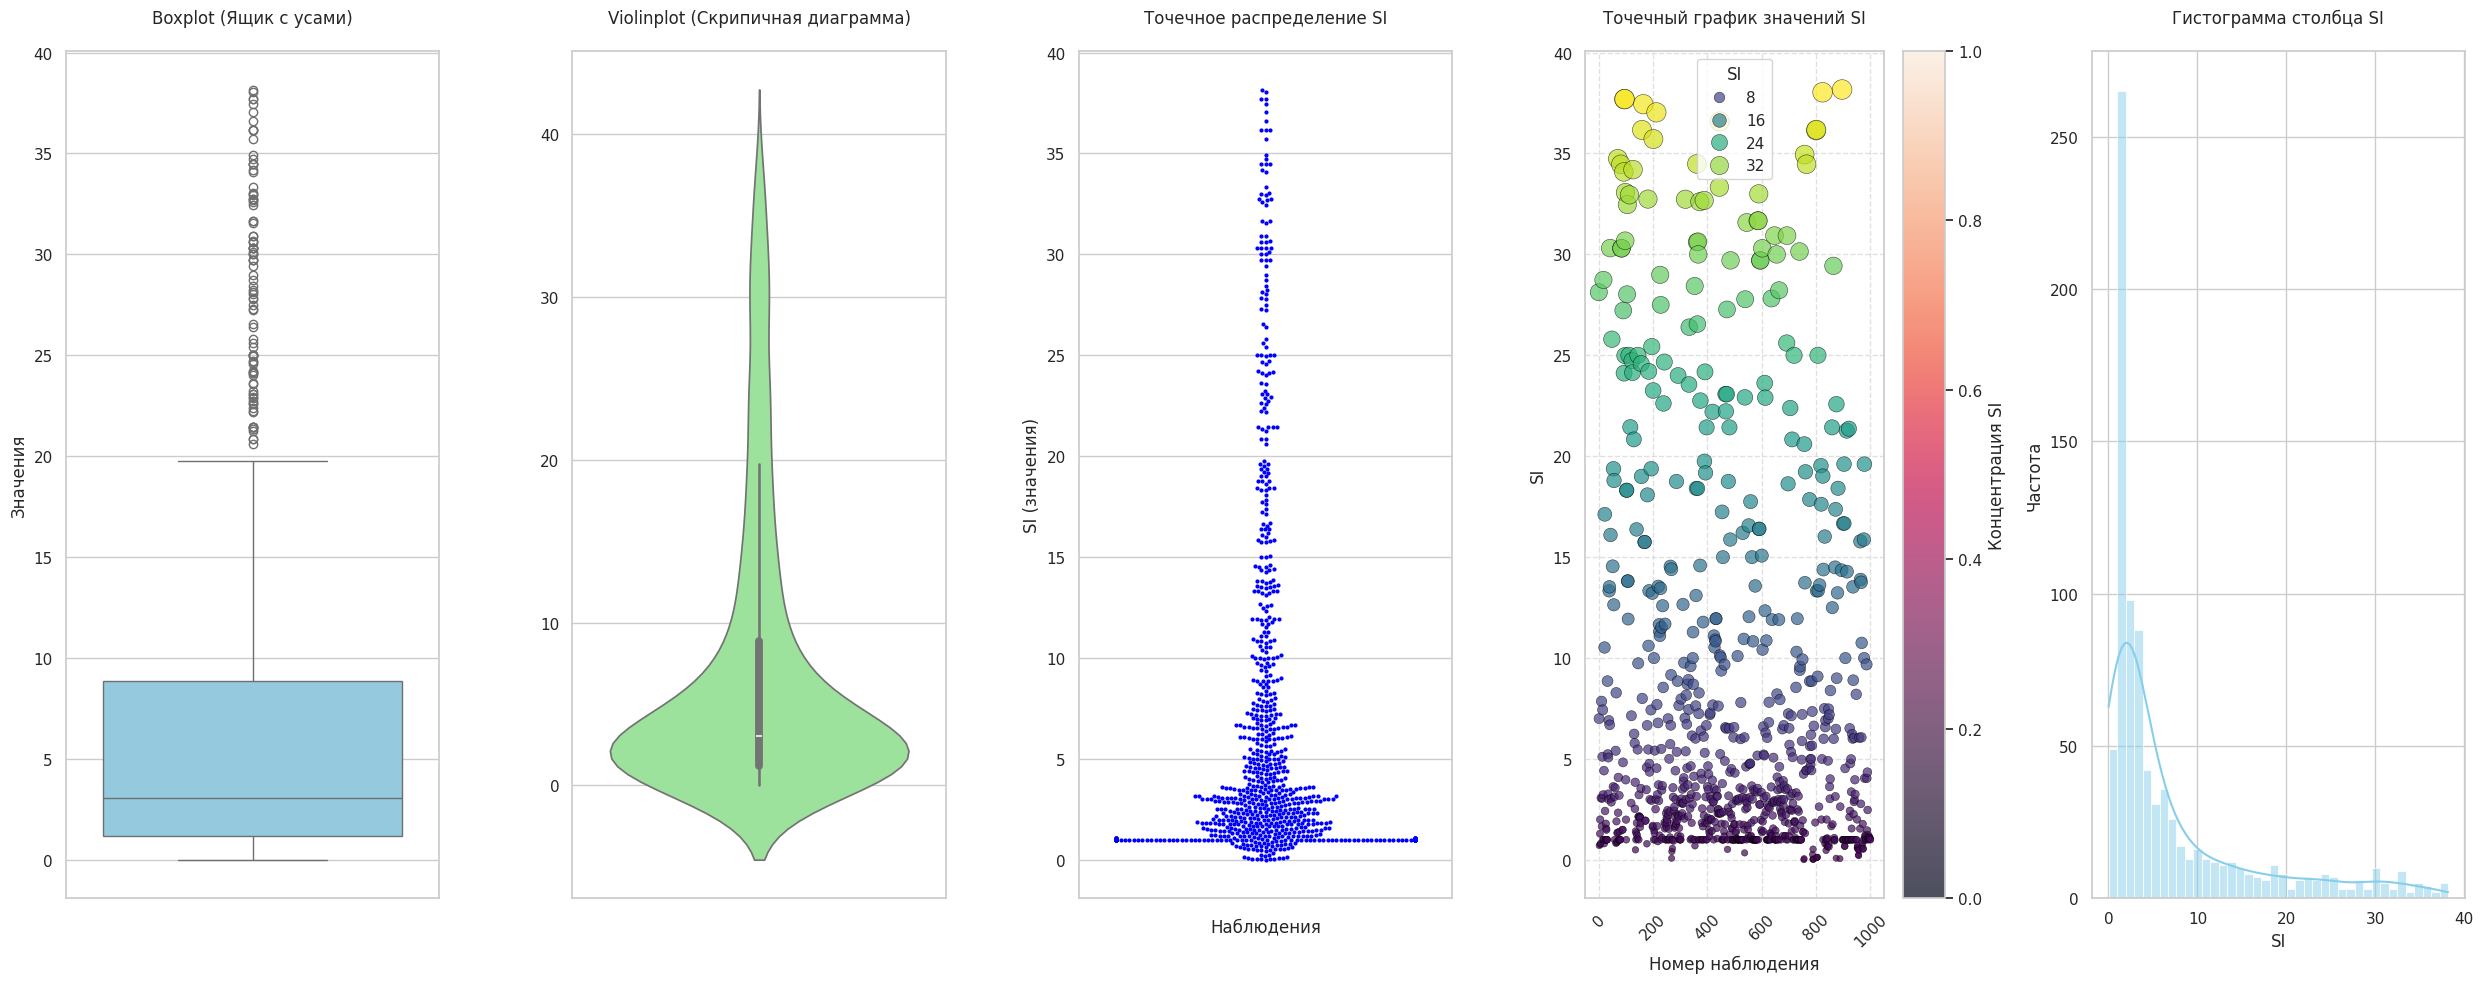


Анализ выбросов:
- Количество выбросов по SI: 97
- Нижняя граница (нижний квантиль минус 1.5*IQR): -10.296
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 20.347



In [37]:
# Вывод информации о столбцах датасета data_for_SI
visualize_column(data_for_SI, 'SI')

# Исследуем датасет для классификации значения медианы IC50, СС50, SI

In [38]:
data.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [41]:
# Вычисляем медианные значения
IC50_median = data['IC50, mM'].median()
CC50_median = data['CC50, mM'].median()
SI_median = data['SI'].median()
SI_CONST = 8  # Постоянное значение для сравнения SI

# Печать медиан и константы
print(f'Медианное значение IC50: {round(IC50_median, 2)} мМ')
print(f'Медианное значение CC50: {round(CC50_median, 2)} мМ')
print(f'Медианное значение SI: {round(SI_median, 2)}')
print(f'Фиксированная константа SI: {SI_CONST}')

# Новый столбец для бинарной классификации IC50
data['High_IC50'] = (data['IC50, mM'] > IC50_median).astype(int)

# Новый столбец для бинарной классификации CC50
data['High_CC50'] = (data['CC50, mM'] > CC50_median).astype(int)

# Новый столбец для бинарной классификации SI (используя медиану)
data['High_SI'] = (data['SI'] > SI_median).astype(int)

# Новый столбец для бинарной классификации SI (используя фиксированную константу)
data['SI_CONST'] = (data['SI'] > SI_CONST).astype(int)

# Удаляем ненужные столбцы и формируем отдельные датасеты
dataset_IC50_median = data.drop(['CC50, mM', 'SI', 'High_CC50', 'High_SI', 'SI_CONST'], axis=1)
dataset_CC50_median = data.drop(['IC50, mM', 'SI', 'High_IC50', 'High_SI', 'SI_CONST'], axis=1)
dataset_SI_median = data.drop(['IC50, mM', 'CC50, mM', 'High_IC50', 'High_CC50', 'SI_CONST'], axis=1)
dataset_SI_CONST = data.drop(['IC50, mM', 'CC50, mM', 'High_IC50', 'High_CC50', 'High_SI'], axis=1)

# Вывести первые строки датасетов для контроля изменений
print("\nПервые строки нового датасета для IC50:")
print(dataset_IC50_median.head())

print("\nПервые строки нового датасета для CC50:")
print(dataset_CC50_median.head())

print("\nПервые строки нового датасета для SI (медиана):")
print(dataset_SI_median.head())

print("\nПервые строки нового датасета для SI (фиксированный порог):")
print(dataset_SI_CONST.head())

Медианное значение IC50: 46.59 мМ
Медианное значение CC50: 411.04 мМ
Медианное значение SI: 3.85
Фиксированная константа SI: 8

Первые строки нового датасета для IC50:
     IC50, mM  MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  \
0    6.239374           5.094096        5.094096           0.387225   
1    0.771831           3.961417        3.961417           0.533868   
2  223.808778           2.627117        2.627117           0.543231   
3    1.705624           5.097360        5.097360           0.390603   
4  107.131532           5.150510        5.150510           0.270476   

   MinEStateIndex       qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  \
0        0.387225  0.417362  42.928571  384.652         340.300  384.350449   
1        0.533868  0.462473  45.214286  388.684         340.300  388.381750   
2        0.543231  0.260923  42.187500  446.808         388.344  446.458903   
3        0.390603  0.377846  41.862069  398.679         352.311  398.366099   
4        0

/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


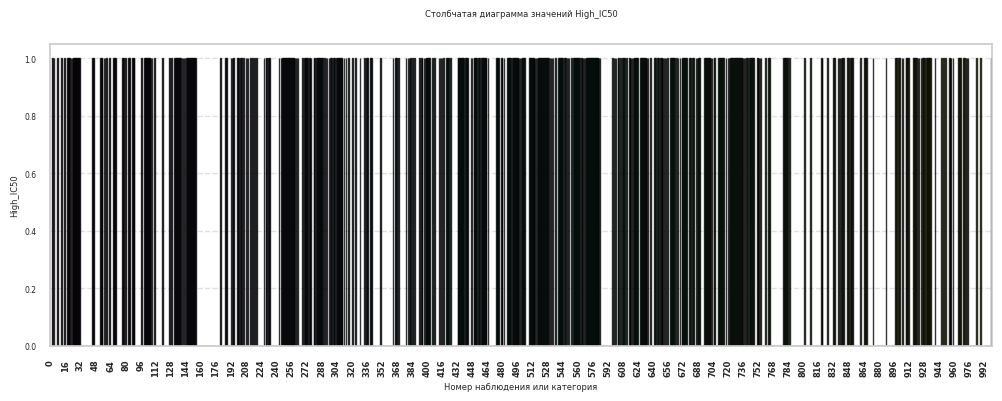

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 86.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


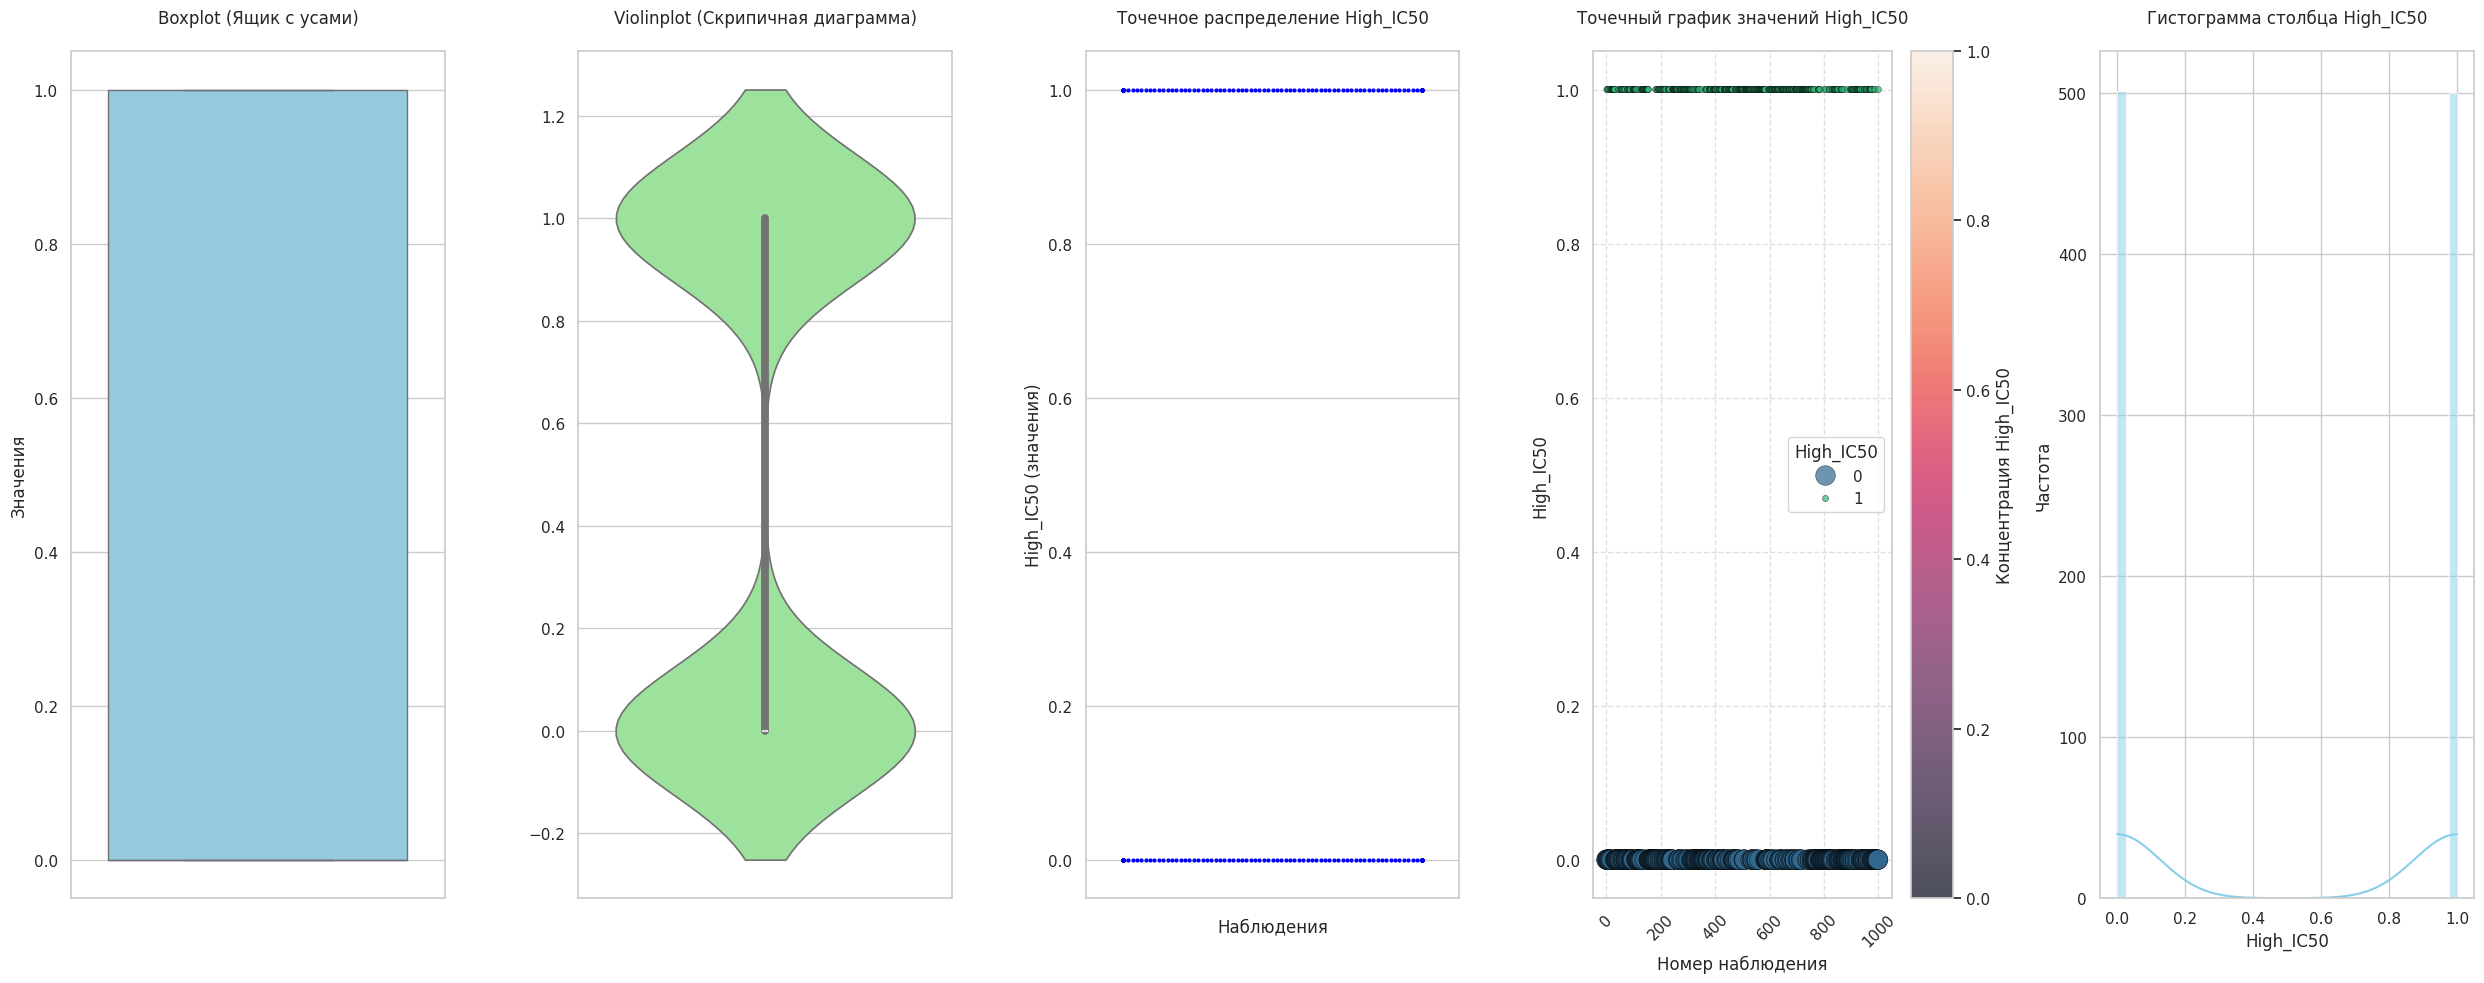


Анализ выбросов:
- Количество выбросов по High_IC50: 0
- Нижняя граница (нижний квантиль минус 1.5*IQR): -1.500
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 2.500



/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


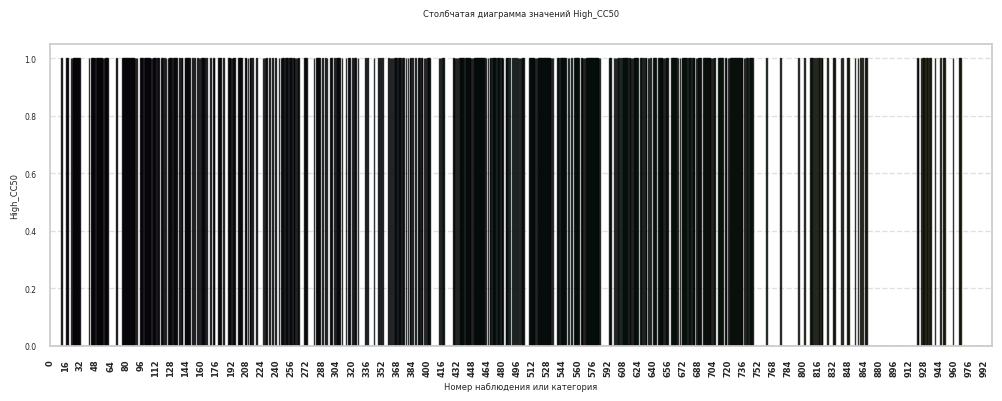

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 86.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


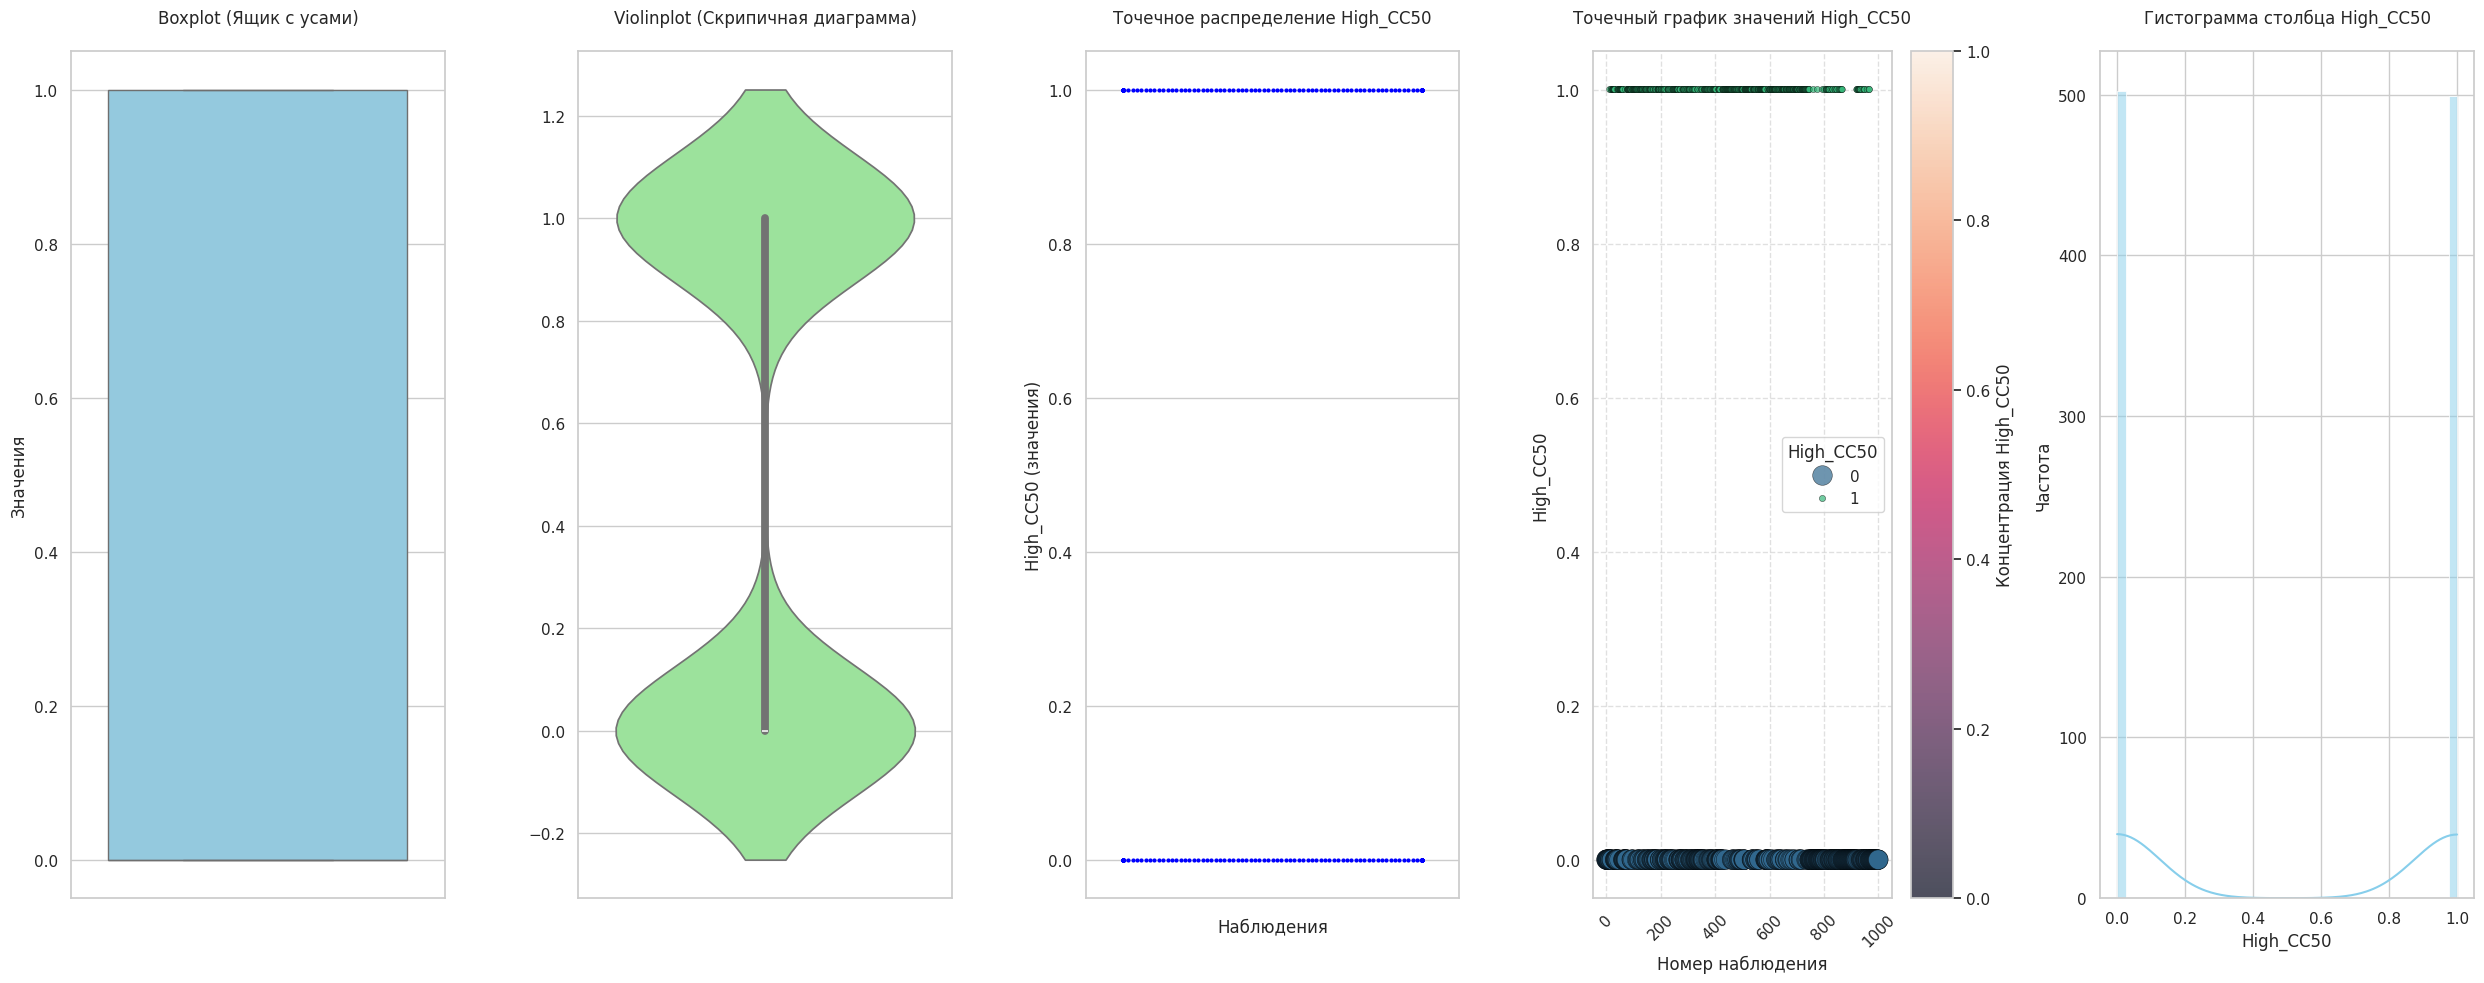


Анализ выбросов:
- Количество выбросов по High_CC50: 0
- Нижняя граница (нижний квантиль минус 1.5*IQR): -1.500
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 2.500



/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


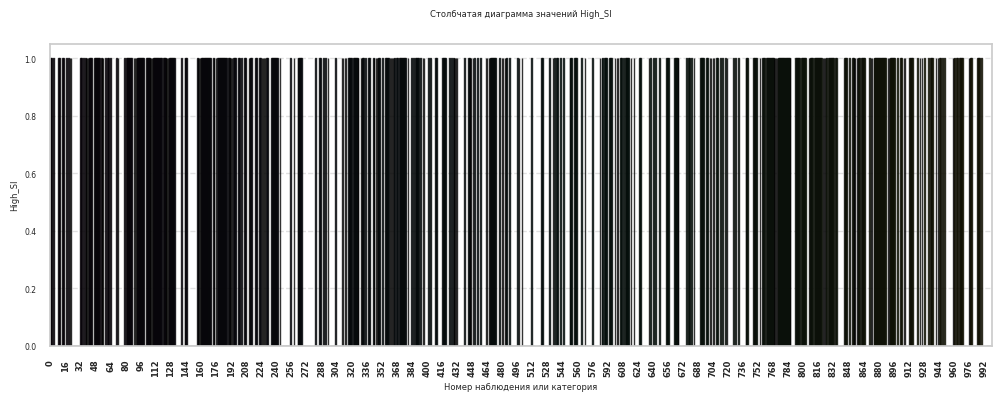

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 86.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


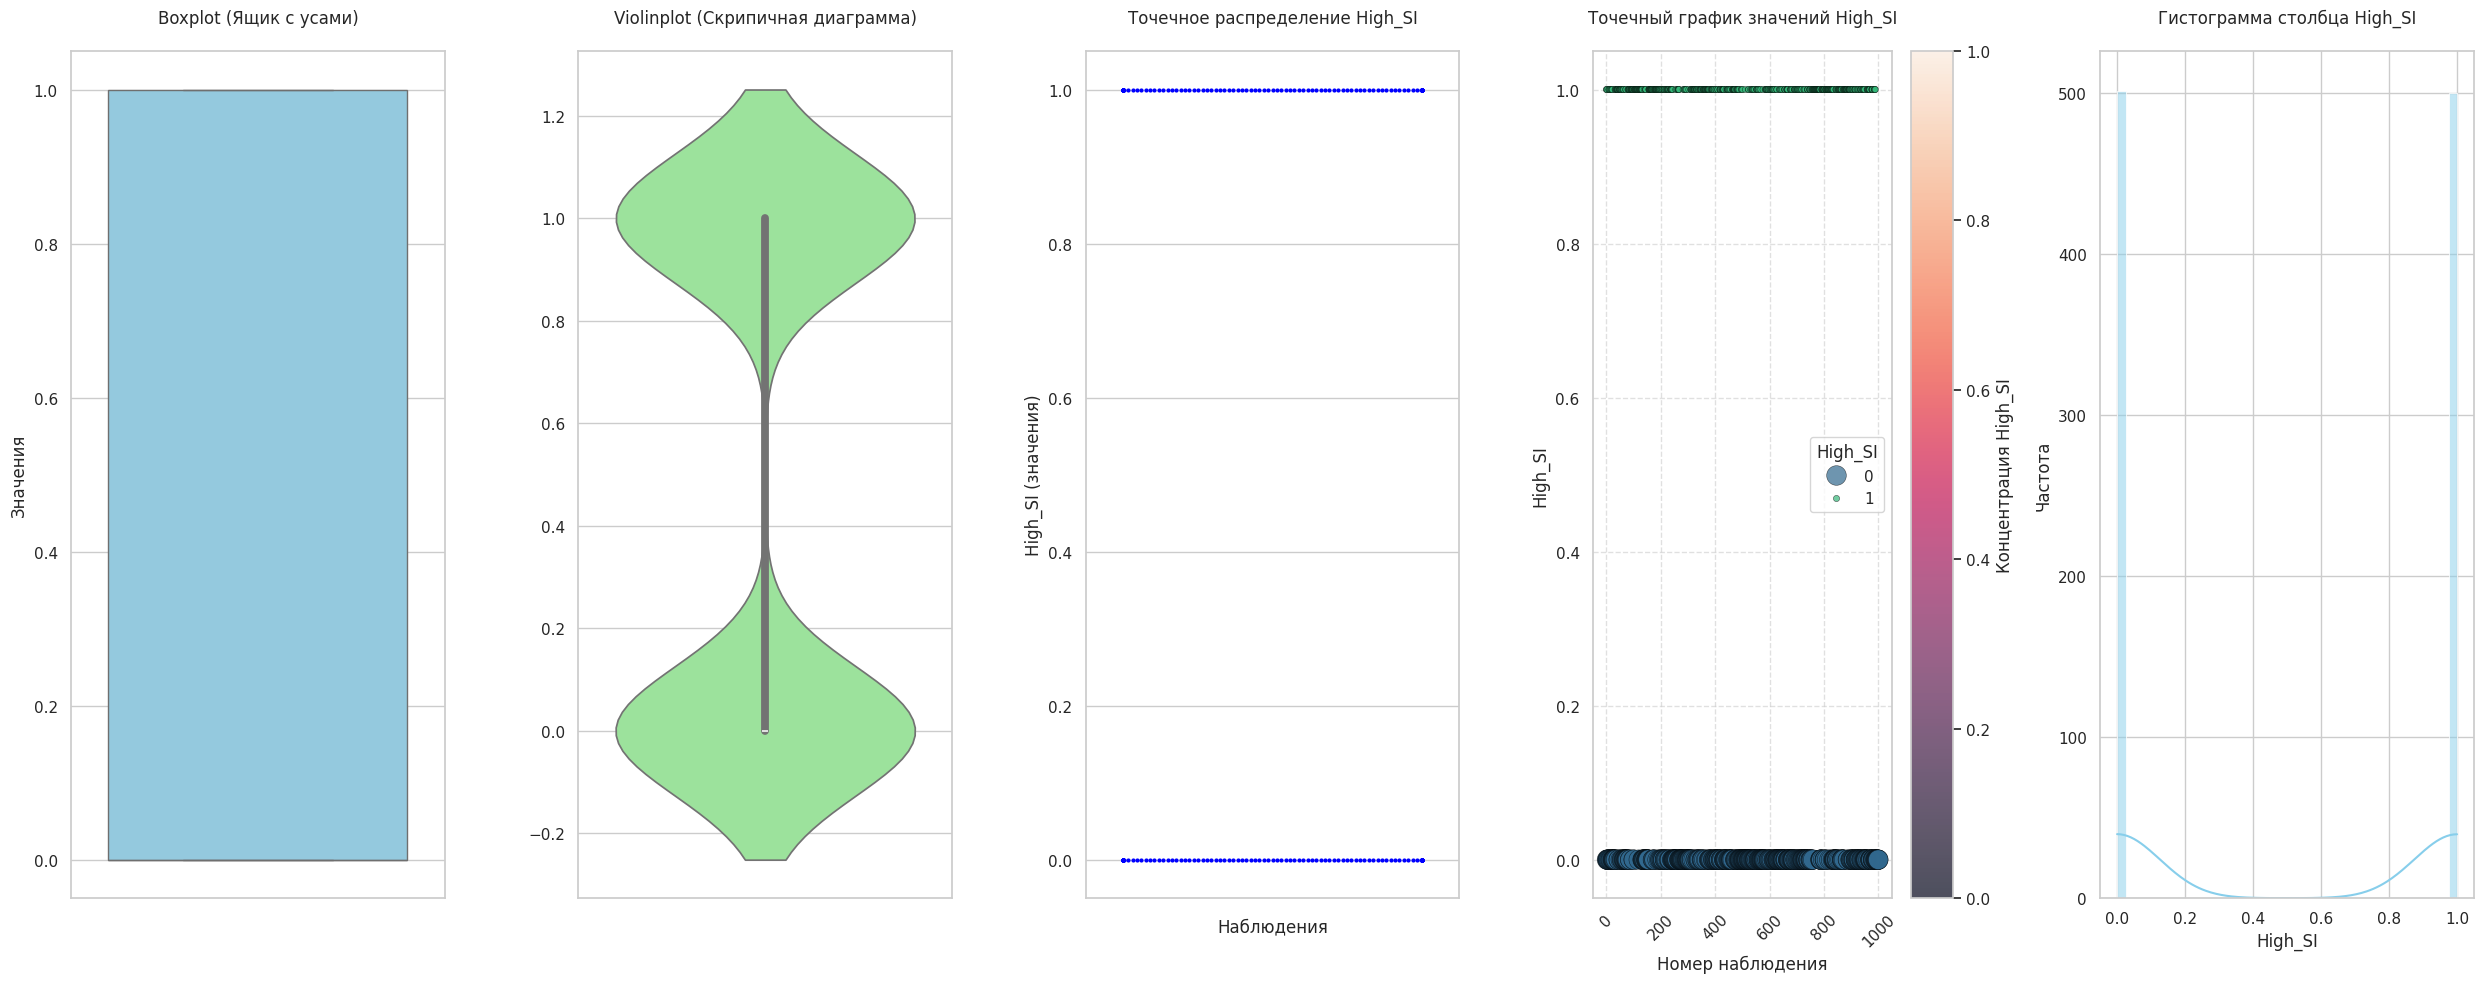


Анализ выбросов:
- Количество выбросов по High_SI: 0
- Нижняя граница (нижний квантиль минус 1.5*IQR): -1.500
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 2.500



/tmp/ipython-input-12-3379085251.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


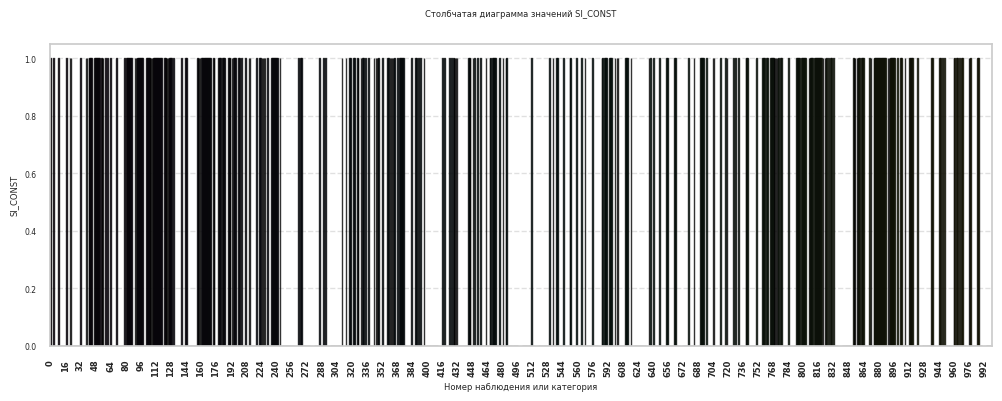

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 86.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


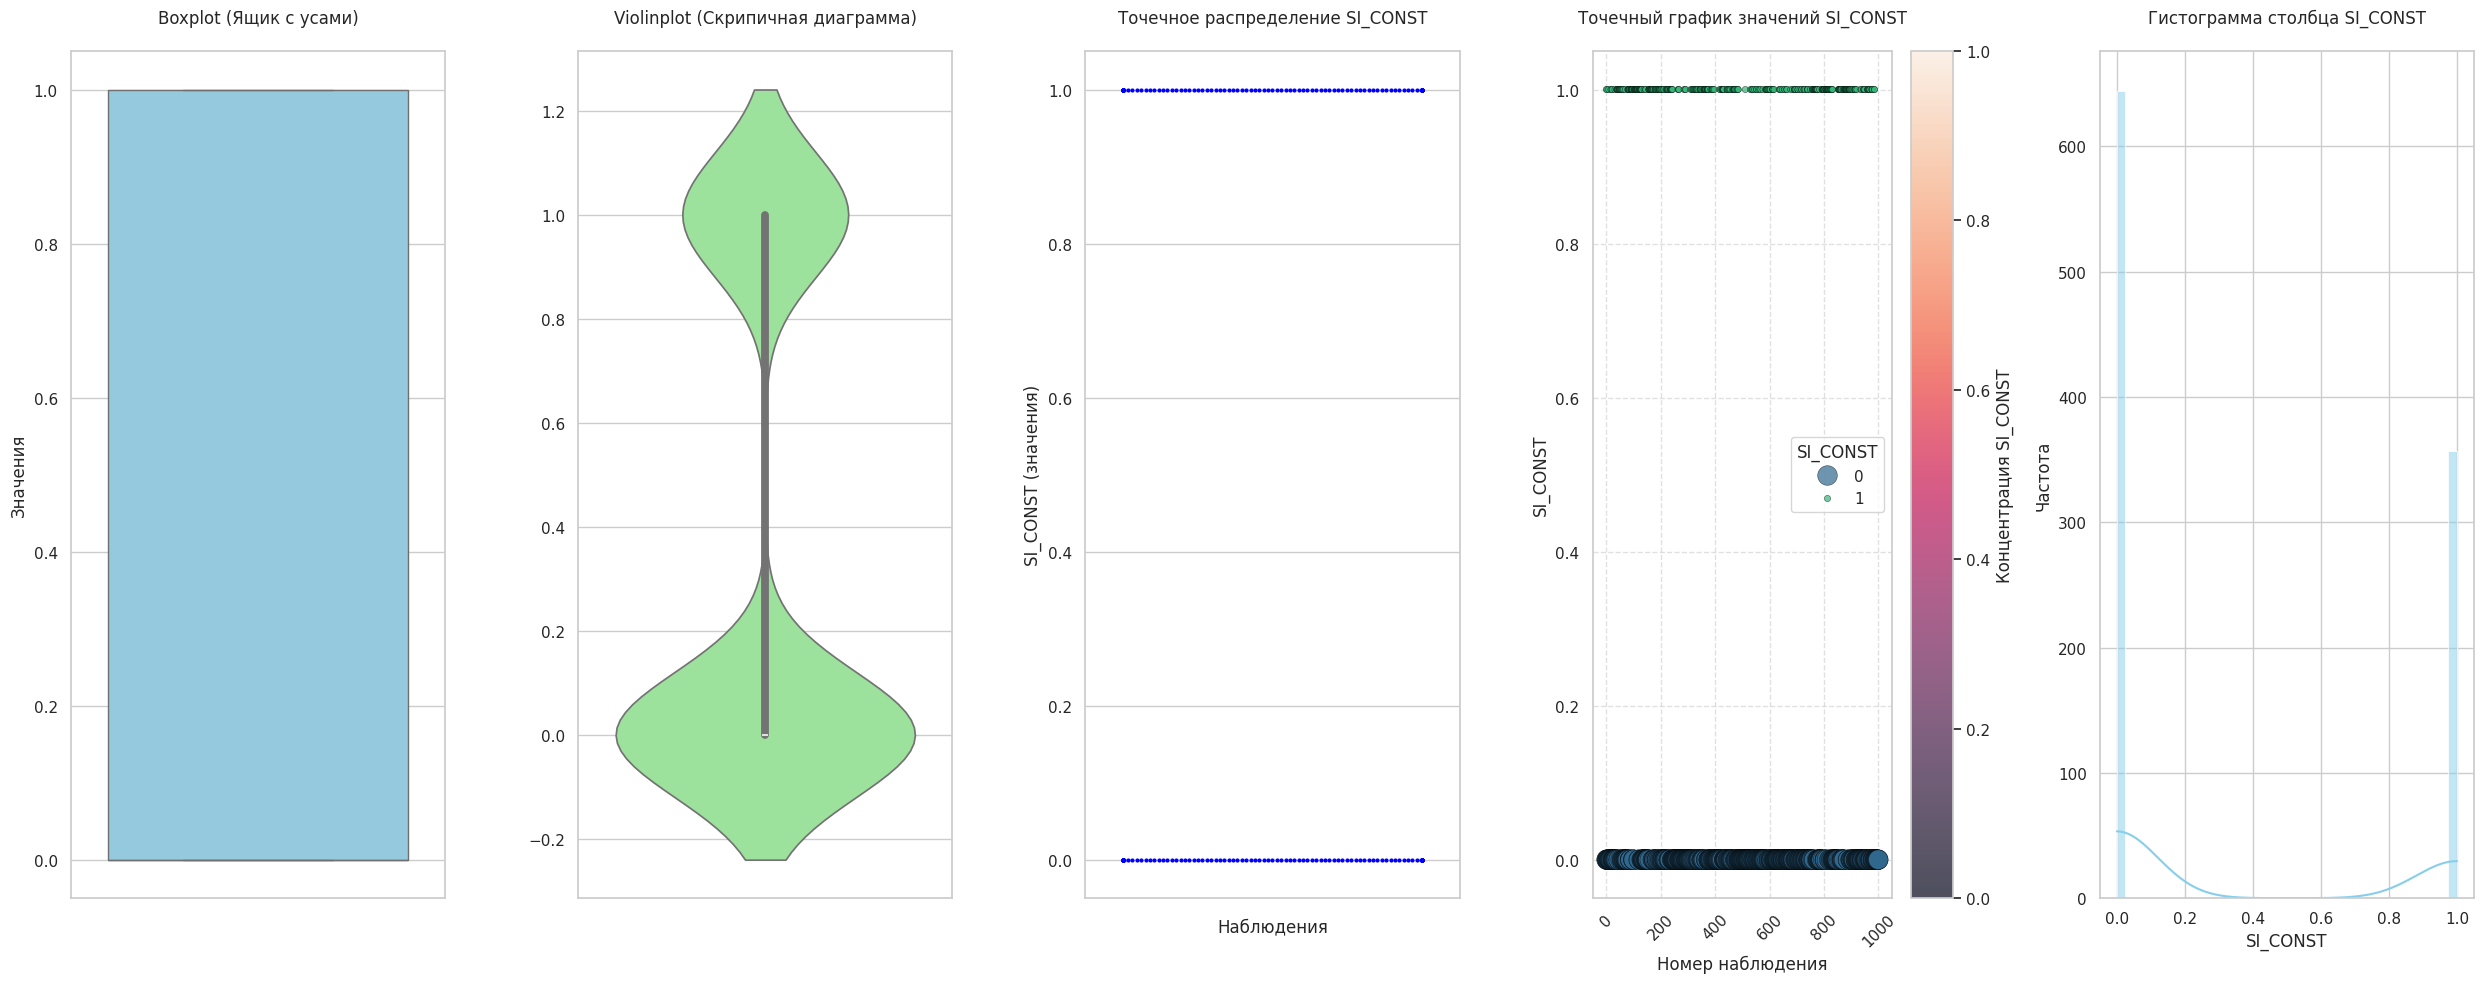


Анализ выбросов:
- Количество выбросов по SI_CONST: 0
- Нижняя граница (нижний квантиль минус 1.5*IQR): -1.500
- Верхняя граница (верхний квантиль плюс 1.5*IQR): 2.500



In [45]:
visualize_column(dataset_IC50_median, 'High_IC50')
visualize_column(dataset_CC50_median, 'High_CC50')
visualize_column(dataset_SI_median, 'High_SI')
visualize_column(dataset_SI_CONST, 'SI_CONST')

In [46]:
dataset_IC50_median.head()


,"IC50, mM",MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,High_IC50
0,6.239374,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,...,0,0,0,0,0,0,0,3,0,0
1,0.771831,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,...,0,0,0,0,0,0,0,3,0,0
2,223.808778,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,...,0,0,0,0,0,0,0,3,0,1
3,1.705624,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,...,0,0,0,0,0,0,0,4,0,0
4,107.131532,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,...,0,0,0,0,0,0,0,0,0,1


In [47]:
dataset_CC50_median.head()


,"CC50, mM",MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,High_CC50
0,175.482382,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,...,0,0,0,0,0,0,0,3,0,0
1,5.402819,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,...,0,0,0,0,0,0,0,3,0,0
2,161.142320,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,...,0,0,0,0,0,0,0,3,0,0
3,107.855654,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,...,0,0,0,0,0,0,0,4,0,0
4,139.270991,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,...,0,0,0,0,0,0,0,0,0,0


In [48]:
dataset_SI_median.head()


,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,High_SI
0,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,...,0,0,0,0,0,0,0,3,0,1
1,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,...,0,0,0,0,0,0,0,3,0,1
2,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,...,0,0,0,0,0,0,0,3,0,0
3,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,...,0,0,0,0,0,0,0,4,0,1
4,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,...,0,0,0,0,0,0,0,0,0,0


In [50]:
dataset_SI_CONST.head()

,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,SI_CONST
0,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,...,0,0,0,0,0,0,0,3,0,1
1,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,...,0,0,0,0,0,0,0,3,0,0
2,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,...,0,0,0,0,0,0,0,3,0,0
3,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,...,0,0,0,0,0,0,0,4,0,1
4,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,...,0,0,0,0,0,0,0,0,0,0


In [52]:
# Сохранение всех датасетов в формате CSV
data_for_CC50_962.to_csv('dataset_for_CC50_962.csv', index=False, encoding='utf-8')

data_for_IC50_854.to_csv('dataset_for_IC50_854.csv', index=False, encoding='utf-8')

data_for_SI.to_csv('dataset_for_SI.csv', index=False, encoding='utf-8')
data_for_SI.to_csv('dataset_for_SI.csv', index=False, encoding='utf-8')

dataset_IC50_median.to_csv('dataset_IC50_median.csv', index=False, encoding='utf-8')
dataset_CC50_median.to_csv('dataset_CC50_median.csv', index=False, encoding='utf-8')
dataset_SI_median.to_csv('dataset_SI_median.csv', index=False, encoding='utf-8')

dataset_SI_CONST.to_csv('dataset_SI_const.csv', index=False, encoding='utf-8')





